In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('../data/survey_data.csv')
df.fillna(0,inplace=True)

I_fresh  = ((df["근속년수"] >= 0)  & (df["근속년수"] < 3)).astype(int)
I_junior = ((df["근속년수"] >= 3)  & (df["근속년수"] < 10)).astype(int)
I_middle = ((df["근속년수"] >= 10) & (df["근속년수"] < 20)).astype(int)
I_senior = (df["근속년수"] >= 20).astype(int)

df = df.drop(columns='근속년수')
df["근속년수_구분"] = 1 * I_fresh + 2 * I_junior + 3 * I_middle + 4 * I_senior

CL_map = {'CL1' : 1 , 'CL2' : 2 ,  'CL3' : 3, 'CL4':4}
degree_map = {'고졸' : 1, '학사':2, '석사':2,'박사':3}
group_map = {'A그룹' : 1, 'B그룹' : 2, 'C그룹' : 3,'D그룹' : 4,
             'E그룹' : 5,'F그룹' : 6,'G그룹' : 7,'H그룹' : 8}

## 이직의사는 DataGeneration.py에서 이미 1(이직 의사 없음)~5(매우 높음) 순서형 점수로 생성되므로
## 별도 map 없이 그대로 사용한다.
df['직급'] = df['직급'].map(CL_map)
df['학력'] = df['학력'].map(degree_map)


df_group = pd.DataFrame(df['소속'].map(group_map),columns=['소속'])
#시각화를 위해 별도 분리

df = pd.get_dummies(df, columns=['소속'],drop_first=False)

df.head(10)

,idx,직급,학력,이직의사,조직문화평가_복지,조직문화평가_회의,조직문화평가_교육,조직문화평가_업무,조직문화평가_상사,조직문화평가_부서,...,통합점수_전년대비증감,근속년수_구분,소속_A그룹,소속_B그룹,소속_C그룹,소속_D그룹,소속_E그룹,소속_F그룹,소속_G그룹,소속_H그룹
0,0,4,2,3,4.0,4.0,4.0,3.0,3.0,5.0,...,-2.5,3,True,False,False,False,False,False,False,False
1,1,3,3,2,0.0,0.0,0.0,0.0,0.0,0.0,...,-13.1,3,True,False,False,False,False,False,False,False
2,2,4,2,1,4.0,4.0,5.0,3.0,4.0,4.0,...,-0.9,4,False,True,False,False,False,False,False,False
3,3,4,2,3,0.0,0.0,0.0,0.0,0.0,0.0,...,-6.4,4,False,False,False,False,False,False,False,True
4,4,2,2,1,2.0,2.0,3.0,3.0,3.0,5.0,...,-8.2,2,False,False,False,True,False,False,False,False
5,5,4,2,2,2.0,3.0,4.0,3.0,2.0,3.0,...,-9.9,4,False,False,False,False,False,True,False,False
6,6,4,2,3,3.0,4.0,3.0,5.0,4.0,4.0,...,3.0,4,False,False,False,True,False,False,False,False
7,7,4,1,4,0.0,0.0,0.0,0.0,0.0,0.0,...,-14.8,4,False,True,False,False,False,False,False,False
8,8,2,2,3,4.0,4.0,4.0,3.0,3.0,3.0,...,-8.0,3,False,False,True,False,False,False,False,False
9,9,3,2,1,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.3,3,True,False,False,False,False,False,False,False


In [2]:
TRAIN_FEATURE_SURVEY = ['복지','회의','교육','업무','상사','동료']
TRAIN_FEATURE_IDENTITY = ['직급','학력','근속년수_구분', '소속_A그룹',
       '소속_B그룹', '소속_C그룹', '소속_D그룹', '소속_E그룹', '소속_F그룹', '소속_G그룹', '소속_H그룹']
GROUP_ITER = ['소속_A그룹',
       '소속_B그룹', '소속_C그룹', '소속_D그룹', '소속_E그룹', '소속_F그룹', '소속_G그룹', '소속_H그룹']
df_selection = pd.DataFrame()
for item in TRAIN_FEATURE_SURVEY:
    df_selection[item] = df[f'조직문화평가_{item}']
for item in TRAIN_FEATURE_IDENTITY:
    df_selection[item] = df[item]

df_selection['회의'] = df['1Q_업무몰입도평가_회의'] + df['2Q_업무몰입도평가_회의']
df_selection['업무'] = df['1Q_업무몰입도평가_고객'] + df['2Q_업무몰입도평가_고객'] + df['1Q_업무몰입도평가_기술력'] + df['2Q_업무몰입도평가_기술력']
df_selection['상사'] = df['1Q_업무몰입도평가_보고'] + df['2Q_업무몰입도평가_보고'] + df['1Q_업무몰입도평가_소통'] + df['2Q_업무몰입도평가_소통']
df_selection.head(10)

,복지,회의,교육,업무,상사,동료,직급,학력,근속년수_구분,소속_A그룹,소속_B그룹,소속_C그룹,소속_D그룹,소속_E그룹,소속_F그룹,소속_G그룹,소속_H그룹
0,4.0,0.0,4.0,0.0,0.0,2.0,4,2,3,True,False,False,False,False,False,False,False
1,0.0,3.0,0.0,5.0,8.0,0.0,3,3,3,True,False,False,False,False,False,False,False
2,4.0,3.0,5.0,12.0,11.0,4.0,4,2,4,False,True,False,False,False,False,False,False
3,0.0,0.0,0.0,0.0,0.0,0.0,4,2,4,False,False,False,False,False,False,False,True
4,2.0,8.0,3.0,11.0,11.0,2.0,2,2,2,False,False,False,True,False,False,False,False
5,2.0,3.0,4.0,9.0,7.0,1.0,4,2,4,False,False,False,False,False,True,False,False
6,3.0,0.0,3.0,0.0,0.0,4.0,4,2,4,False,False,False,True,False,False,False,False
7,0.0,4.0,0.0,9.0,9.0,0.0,4,1,4,False,True,False,False,False,False,False,False
8,4.0,5.0,4.0,6.0,9.0,4.0,2,2,3,False,False,True,False,False,False,False,False
9,0.0,3.0,0.0,5.0,7.0,0.0,3,2,3,True,False,False,False,False,False,False,False


In [3]:
X = df_selection[['복지','회의','교육','업무','상사','동료', '직급','학력','근속년수_구분','소속_A그룹',
       '소속_B그룹', '소속_C그룹', '소속_D그룹', '소속_E그룹', '소속_F그룹', '소속_G그룹', '소속_H그룹']]
y = df['이직의사']

X_tn, X_te, y_tn, y_te = train_test_split(X,y,random_state=0,stratify=y)

std = StandardScaler()
std.fit(X_tn)

X_tn_std = std.transform(X_tn)
X_te_std = std.transform(X_te)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rfc = RandomForestClassifier(random_state=0)

rfc.fit(X_tn_std,y_tn)
y_pred_rfc = rfc.predict(X_te_std)

print(rfc.feature_importances_)
report = classification_report(y_te, y_pred_rfc)
print('========RandomForest===========')
print(report)

[0.08667151 0.09951804 0.07691037 0.12381185 0.13644587 0.07799053
 0.07453863 0.0455009  0.07091508 0.02566771 0.02090906 0.02687778
 0.02957562 0.02537071 0.0283143  0.02470959 0.02627245]
========RandomForest===========
              precision    recall  f1-score   support

           1       0.32      0.41      0.36        32
           2       0.24      0.22      0.23        23
           3       0.42      0.44      0.43        25
           4       0.06      0.05      0.05        22
           5       0.14      0.09      0.11        11

    accuracy                           0.27       113
   macro avg       0.24      0.24      0.24       113
weighted avg       0.26      0.27      0.26       113



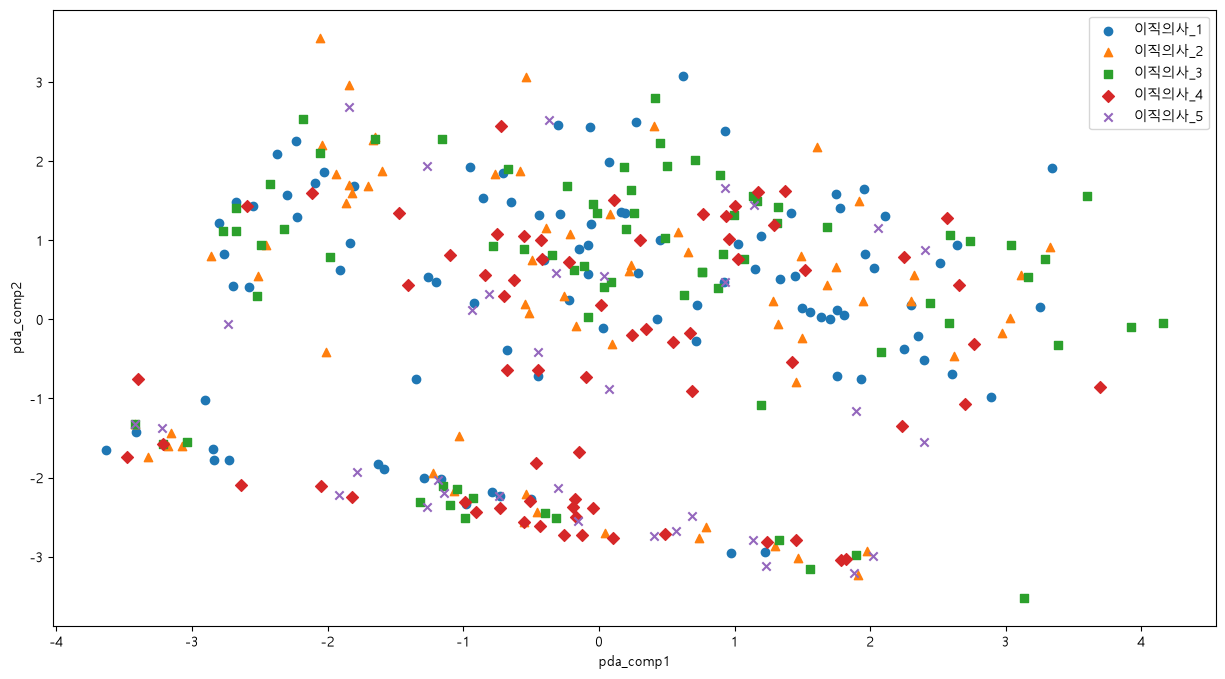

In [5]:
##전체 Feature에 대한 PDA의 수행결과로 인한 2차원 분포
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

pca = PCA(n_components=2)
pca.fit(X_tn_std)

X_tn_pca = pca.transform(X_tn_std)
X_te_pca = pca.transform(X_te_std)

X_tn_pda_df = pd.DataFrame(X_tn_pca, columns=['pda_comp1', 'pda_comp2'])

X_tn_pda_df['target'] = df.loc[X_tn.index, '이직의사'].values

plt.figure(figsize=(15,8))

markers = {1: 'o', 2: '^', 3: 's', 4: 'D', 5: 'x'}

for level in range(1, 6):
    df_level = X_tn_pda_df[X_tn_pda_df['target'] == level]
    plt.scatter(df_level['pda_comp1'], df_level['pda_comp2'],
                marker=markers[level], label=f'이직의사_{level}')

plt.xlabel('pda_comp1')
plt.ylabel('pda_comp2')
plt.legend()
plt.show()

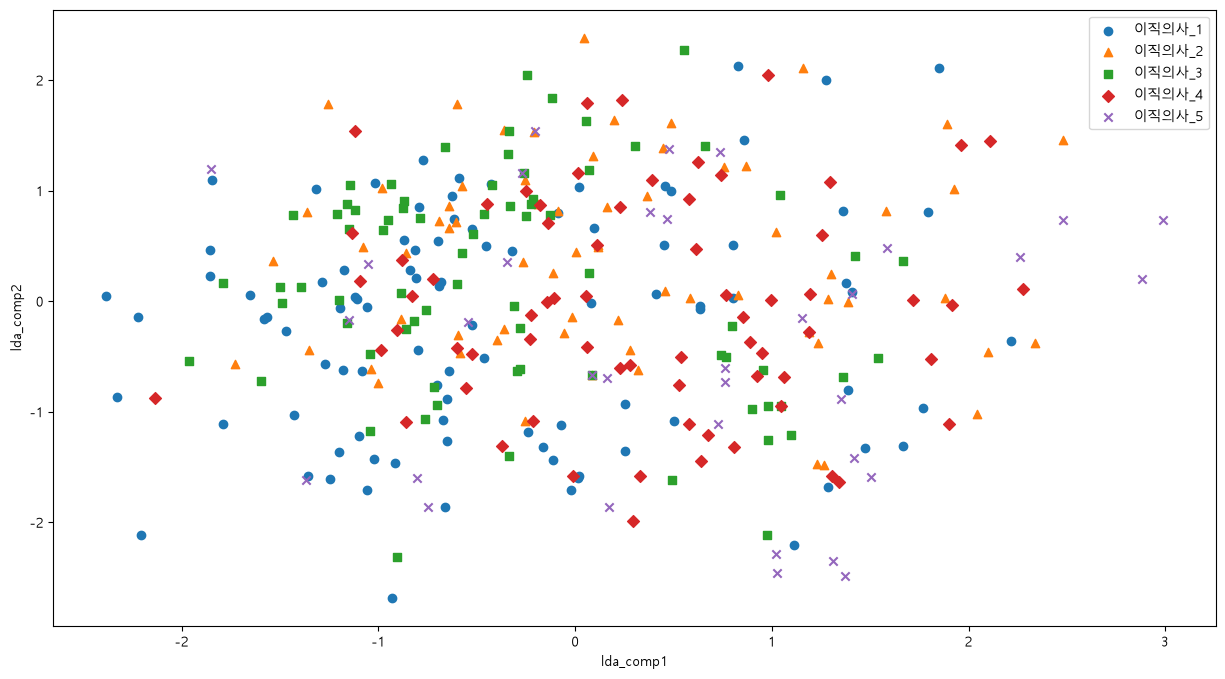

In [6]:
## 결합 LDA(2D) 시각화
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


plt.figure(figsize=(15,8))

lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_tn_std, y_tn)
X_tn_lda_combined = lda.transform(X_tn_std)

X_tn_lda_combined_df = pd.DataFrame(X_tn_lda_combined, columns=['lda_comp1', 'lda_comp2'])
X_tn_lda_combined_df['target'] = y_tn.values

for level in range(1, 6):
    df_level = X_tn_lda_combined_df[X_tn_lda_combined_df['target'] == level]
    plt.scatter(df_level['lda_comp1'], df_level['lda_comp2'],
                marker=markers[level], label=f'이직의사_{level}')

plt.xlabel('lda_comp1')
plt.ylabel('lda_comp2')
plt.legend()
plt.show()

In [7]:
## 소속 및 신원의 LDA와 설문 결과으 LDA로 2차원 분포
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_survey = df_selection[TRAIN_FEATURE_SURVEY]
X_identitiy = df_selection[TRAIN_FEATURE_IDENTITY]
y = df['이직의사']
lda = LinearDiscriminantAnalysis(n_components=1)

X_tn_sur, X_te_sur, y_tn_sur, y_te_sur = train_test_split(X_survey, y, random_state=0, stratify=y)
X_tn_id, X_te_id, y_tn_id, y_te_id = train_test_split(X_identitiy, y, random_state=0, stratify=y)

lda.fit(X_tn_sur, y_tn_sur)
X_tn_lda_sur = lda.transform(X_tn_sur)
X_te_lda_sur = lda.transform(X_te_sur)


lda.fit(X_tn_id, y_tn_id)
X_tn_lda_id = lda.transform(X_tn_id)
X_te_lda_id = lda.transform(X_te_id)

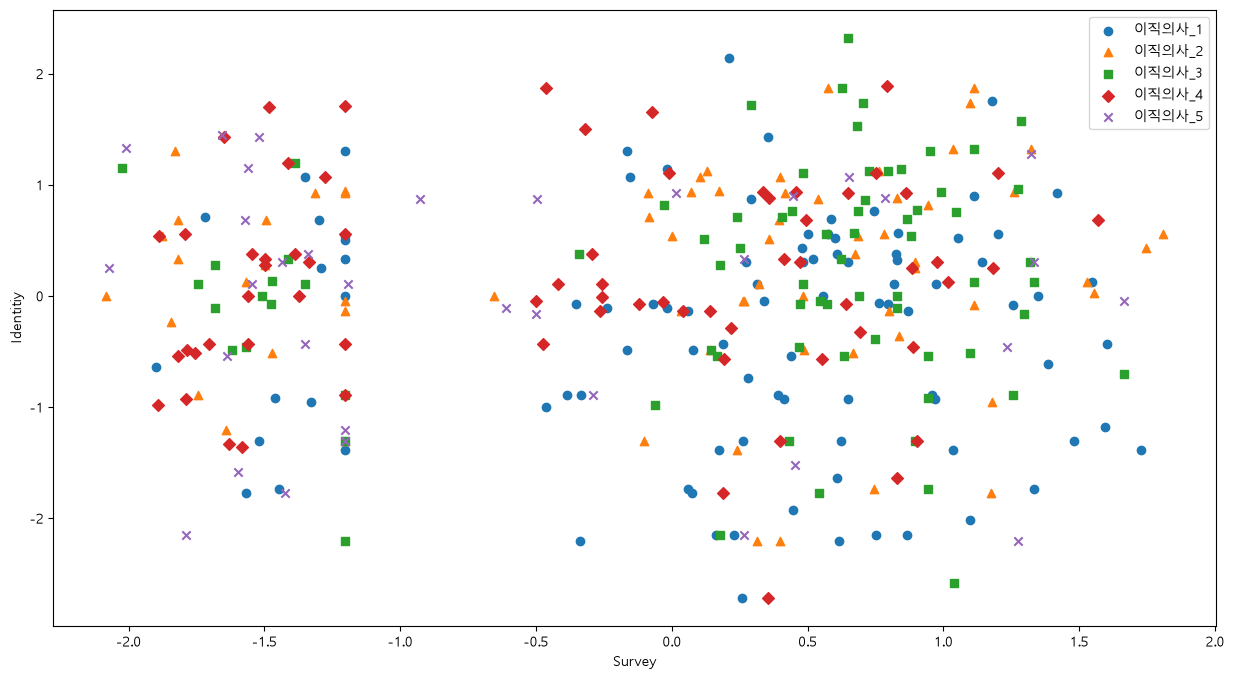

In [8]:
## 2차원으로 LDA축 기준 분포도 시각화

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

X_tn_lda_df = pd.DataFrame(X_tn_lda_sur, columns=['lda_survey'])
X_tn_lda_df['lda_identitiy'] = X_tn_lda_id

X_tn_lda_df['target'] = df.loc[X_tn_sur.index, '이직의사'].values

plt.figure(figsize=(15,8))

markers = {1: 'o', 2: '^', 3: 's', 4: 'D', 5: 'x'}

for level in range(1, 6):
    df_level = X_tn_lda_df[X_tn_lda_df['target'] == level]
    plt.scatter(df_level['lda_survey'], df_level['lda_identitiy'],
                marker=markers[level], label=f'이직의사_{level}')

plt.xlabel('Survey')
plt.ylabel('Identitiy')
plt.legend()
plt.show()

In [9]:
df_group.join(df['이직의사']).mean()
df_group.join(df['이직의사']).groupby('소속')['이직의사'].mean()

소속
1    2.540000
2    2.361702
3    2.901961
4    2.730159
5    2.692308
6    2.688525
7    2.728814
8    2.407407
Name: 이직의사, dtype: float64

In [10]:
## LDA/RandomForest 모두 5점(고위험)을 분류로는 못 잡아냈으니,
## 대신 Isolation Forest(비지도 이상치 탐지)로 5점 인원이 실제로 이상치로 더 많이 걸리는지 확인한다.
## LOF는 거리/밀도 기반이라 17차원처럼 차원이 높아지면 거리 개념이 희석되는 curse of dimensionality에 취약했다
## (실제로 337명 중 6명만 -1로 잡혔다). Isolation Forest는 거리 계산 없이 랜덤 분할로 고립도를 측정하므로
## 고차원에서 상대적으로 더 안정적이다.
## 압축된 좌표가 아니라 원래 표준화된 17개 피처 공간(X_tn_std)에서 고립도를 봐야 하므로 여기서 바로 수행한다.
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(random_state=0)
iso_forest.fit(X_tn_std)

iso_predict = iso_forest.predict(X_tn_std)
print(iso_predict)

[ 1  1  1  1  1  1  1 -1  1 -1 -1  1  1  1 -1  1  1 -1  1 -1 -1 -1  1  1
  1 -1  1  1  1 -1  1 -1 -1  1  1  1  1 -1  1 -1 -1  1  1  1  1 -1 -1 -1
 -1  1 -1 -1  1 -1  1  1 -1 -1 -1  1  1  1  1 -1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1 -1 -1  1  1 -1  1 -1 -1  1 -1  1 -1  1 -1 -1  1  1 -1  1
  1 -1 -1  1  1  1  1  1  1  1 -1  1 -1  1 -1  1 -1  1  1  1  1 -1  1  1
  1  1  1  1  1 -1  1  1  1  1  1 -1 -1 -1  1 -1  1  1 -1 -1  1  1  1  1
  1  1 -1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1 -1  1  1 -1  1 -1 -1
  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1 -1  1  1  1 -1  1  1  1  1 -1  1  1  1  1
  1  1  1 -1 -1 -1  1  1  1  1  1  1  1 -1 -1  1  1  1 -1  1  1  1  1  1
  1  1 -1 -1  1 -1  1  1  1  1  1  1  1 -1  1 -1  1  1 -1  1 -1 -1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1 -1  1  1 -1  1 -1  1  1  1 -1  1  1
  1  1  1  1 -1 -1  1 -1  1  1  1  1  1  1 -1  1  1

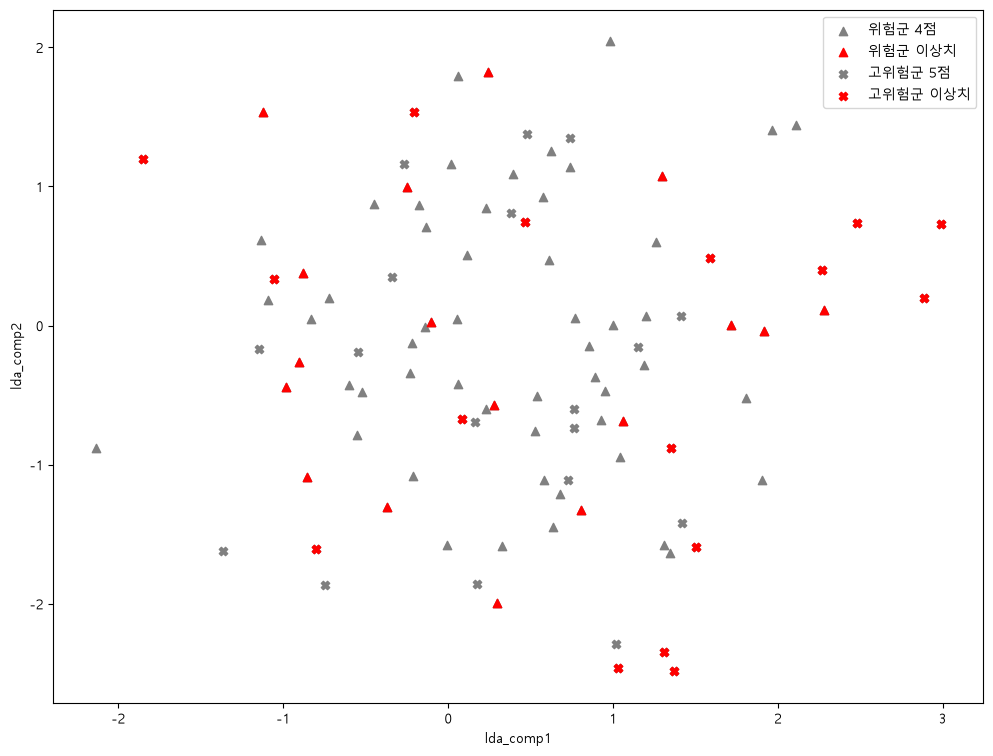

고위험군(4~5점): 68명, 그 중 이상치: 17명 (25.0%)


In [11]:
## 여러 임베딩을 비교하는 대신 결합 LDA(2D)를 직접 선택한다.
## 이직 고위험군(4~5점) 데이터만 산점도로 그리고, 그 위에 Isolation Forest 이상치를 표시한다.
outlier_mask = iso_predict == -1
high_risk_mask = X_tn_lda_combined_df['target'] == 4
high_risk_outlier_mask = high_risk_mask & outlier_mask

ext_high_risk_mask = X_tn_lda_combined_df['target'] == 5
ext_high_risk_outlier_mask = ext_high_risk_mask & outlier_mask
plt.figure(figsize=(12, 9))

plt.scatter(X_tn_lda_combined_df.loc[high_risk_mask, 'lda_comp1'],
           X_tn_lda_combined_df.loc[high_risk_mask, 'lda_comp2'],
           marker='^',
           c='gray', label='위험군 4점')
plt.scatter(X_tn_lda_combined_df.loc[high_risk_outlier_mask, 'lda_comp1'],
           X_tn_lda_combined_df.loc[high_risk_outlier_mask, 'lda_comp2'],
           c='red', marker='^', label='위험군 이상치')

plt.scatter(X_tn_lda_combined_df.loc[ext_high_risk_mask, 'lda_comp1'],
           X_tn_lda_combined_df.loc[ext_high_risk_mask, 'lda_comp2'],
           c='gray', marker='X', label='고위험군 5점')
plt.scatter(X_tn_lda_combined_df.loc[ext_high_risk_outlier_mask, 'lda_comp1'],
           X_tn_lda_combined_df.loc[ext_high_risk_outlier_mask, 'lda_comp2'],
           c='red', marker='X', label='고위험군 이상치')



plt.xlabel('lda_comp1')
plt.ylabel('lda_comp2')
plt.legend()
plt.show()

print(f'고위험군(4~5점): {high_risk_mask.sum()}명, 그 중 이상치: {high_risk_outlier_mask.sum()}명 '
      f'({high_risk_outlier_mask.sum() / high_risk_mask.sum():.1%})')

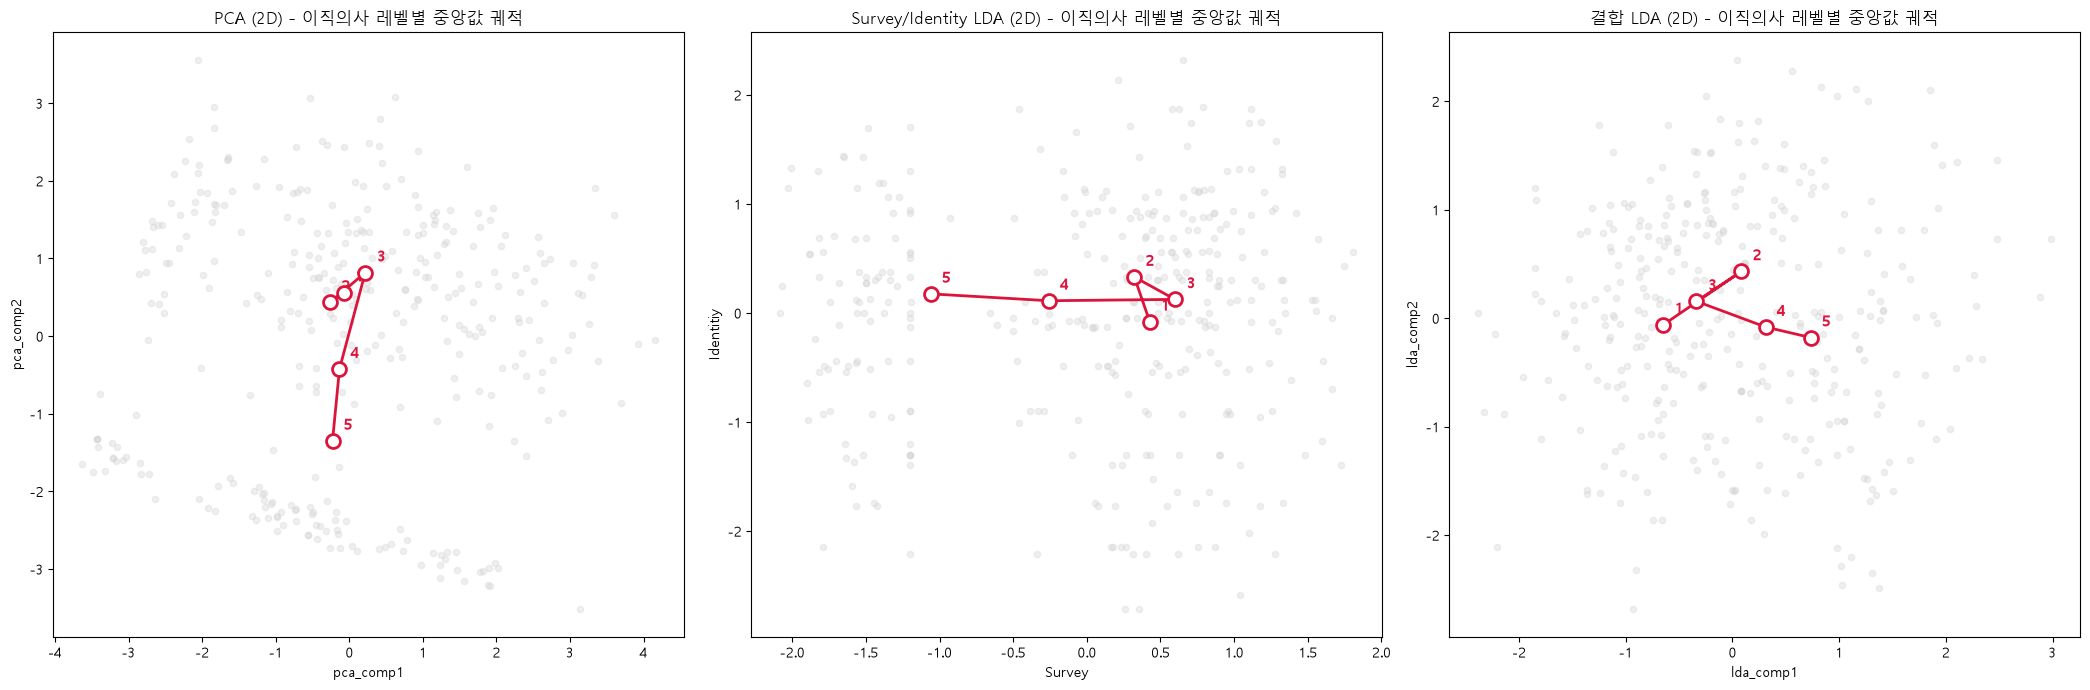

In [12]:
## 실험: 각 임베딩(2D)에서 개별 산점도는 겹침이 심해 추세가 잘 안 보이므로,
## 이직의사 레벨(1~5)별 중앙값(centroid)만 이어서 그려 위험도에 따른 이동 방향이 보이는지 확인한다.
## 배경에는 옅은 산점도를 깔아 중앙값 궤적이 실제 분포 대비 어느 정도인지 함께 보여준다.

def plot_median_trend(ax, df2d, x_col, y_col, title, xlabel, ylabel):
    ax.scatter(df2d[x_col], df2d[y_col], c='lightgray', alpha=0.35, s=20)

    medians = df2d.groupby('target')[[x_col, y_col]].median().sort_index()

    ax.plot(medians[x_col], medians[y_col], c='crimson', linewidth=2,
            marker='o', markersize=10, markerfacecolor='white',
            markeredgecolor='crimson', markeredgewidth=2, zorder=5)

    for level, row in medians.iterrows():
        ax.annotate(str(level), (row[x_col], row[y_col]),
                    textcoords='offset points', xytext=(8, 8),
                    fontsize=11, fontweight='bold', color='crimson')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


fig, axes = plt.subplots(1, 3, figsize=(21, 7))

plot_median_trend(axes[0], X_tn_pda_df, 'pda_comp1', 'pda_comp2',
                   'PCA (2D) - 이직의사 레벨별 중앙값 궤적', 'pca_comp1', 'pca_comp2')
plot_median_trend(axes[1], X_tn_lda_df, 'lda_survey', 'lda_identitiy',
                   'Survey/Identity LDA (2D) - 이직의사 레벨별 중앙값 궤적', 'Survey', 'Identitiy')
plot_median_trend(axes[2], X_tn_lda_combined_df, 'lda_comp1', 'lda_comp2',
                   '결합 LDA (2D) - 이직의사 레벨별 중앙값 궤적', 'lda_comp1', 'lda_comp2')

plt.tight_layout()
plt.show()

## 임베딩 분석 정리 — 생성 알고리즘(DataGeneration.py) 관점

> 세 임베딩(PCA 2D / Survey·Identity LDA / 결합 LDA 2D)에서 이직의사 레벨별 중앙값 궤적을 그려도
> 매끄러운 1→5 추세선은 보이지 않았다. 그 이유와 의미를 데이터 **생성 알고리즘**과 대조해 정리한다.

### 1. 생성 알고리즘이 만든 실제 구조 = "정규분포 몸통 + 극단 꼬리"

`_generate_employment_status()`는 이직의사를 연속 척도가 아니라 다음 구조로 만든다.

- **4~5점 = 극단 꼬리**: `risk_score` 상위 30%를 4점, 상위 10%를 5점으로 배정 (실제 인원 4:90명, 5:45명 → 정확히 30% / 10%)
- **1~3점 = 정규분포 몸통**: 나머지 70%를 z-score 3분위(`norm.ppf(2/3)` 경계)로 1/2/3 배정
- 4~5점(위험군)은 미응답률까지 의도적으로 높임(`AT_RISK_NON_RESPONSE_RATE = 0.4`) → 결측이 0으로 채워지며 점수가 더 낮게 관측됨
- 신원 속성(직급·학력·근속·소속)은 `risk_score`와 **무관하게 독립적으로 생성**됨

레벨별 실제 통계(결측 0 처리 후):

| 이직의사 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| 조직문화 6문항 평균 | 2.69 | 2.45 | 2.80 | **1.91** | **1.58** |
| 조직문화 결측률 | .175 | .267 | .222 | **.378** | **.489** |

→ **1·2·3은 2.4~2.8에 뭉쳐 순서가 없고(3>1>2), 4·5만 뚝 떨어진다.** 이것이 모든 임베딩에서 관찰된 "몸통 vs 꼬리" 패턴의 정체다. 애초에 데이터가 선형 램프가 아니라 "몸통+꼬리"로 설계됐으므로, 매끄러운 1→5 추세선을 기대한 것 자체가 구조와 맞지 않았다.

### 2. 세 임베딩 해석

- **Survey/Identity LDA = 무의미** *(가장 강하게 지지 — 코드로 증명 가능)*
  이직의사는 오직 설문 점수의 변동성·평균에서만 생성되고 신원 속성은 독립 생성되므로, Identity-LDA 축은 정답과 무관한 피처에서 억지로 찾은 **노이즈 방향**이다. 실제 Identity 축 레벨별 중앙값은 −0.08, 0.33, 0.12, 0.11, 0.18로 순서·범위가 거의 없다.

- **PCA (2D) = 최대 분산 방향** *(방향은 맞지만 비지도)*
  PCA는 "분산이 적어지는 방향"이 아니라 **분산이 가장 큰 방향을 남기는 비지도 축소**다. 마침 최대 분산 방향이 4·5의 저점수·고결측 패턴과 겹쳐 결과적으로 꼬리를 분리한다. 즉 정답을 보지 않고(비지도) **우연히** 꼬리를 잡아낸 경우. (comp2 중앙값: 0.56, 0.44, 0.82, −0.42, −1.35 → 1·2·3 뭉침, 4·5 이탈)

- **결합 LDA (2D) = 고위험군을 가리키는 유의미한 방향** *(지지, 단 한정 필요)*
  전체 17개 피처에 대한 지도 축소로, 몸통(1~3)에서 꼬리(4~5)를 떼어내는 방향을 명시적으로 찾는다. (comp1 중앙값: −0.65, 0.08, −0.34, 0.31, 0.73 → 4·5가 양의 방향으로 분리). 단, 분류 test 정확도는 0.24로 최빈값 baseline(0.28)보다 낮아 **1→5 순서를 세우지는 못하며**, "위험도 연속 정렬"이 아니라 "**저위험 몸통에서 고위험 꼬리를 분리하는 방향**"으로 한정해 해석해야 한다.

### 3. 교란요인(보고서에 명시 권장)

4·5의 분리에는 "태도가 낮다"뿐 아니라 **"응답을 덜 해서 0이 많다"(결측률 0.38 / 0.49)**가 크게 기여한다. 이는 생성 설계상 의도된 상관(미응답 ↔ 위험도)이라 정당한 신호지만, 분리 방향이 부분적으로 **응답 성실도(결측 패턴)**를 인코딩한다는 점을 함께 밝혀야 해석이 정직하다.

### 4. 결론 (보고서 문단용)

데이터 생성 알고리즘상 이직의사는 연속 척도가 아니라 정규분포 몸통(1~3점)과 극단 꼬리(상위 30%인 4~5점)로 설계되었고, 신원 속성은 이직의사와 독립적으로 생성되었다. 이 구조는 세 임베딩 결과로 그대로 확인된다. **(1)** Survey/Identity LDA는 이직의사와 무관한 신원 축이 노이즈로 작용해 유의미한 분리를 만들지 못했다. **(2)** PCA는 비지도 축소임에도 최대 분산 방향이 고위험군의 저점수·고결측 패턴과 일치해 4~5점을 분리했다. **(3)** 결합 LDA는 지도 학습으로 몸통과 꼬리를 떼어내는 방향을 명시적으로 찾아, 고위험군을 가리키는 방향성 측면에서 가장 해석 가능한 축을 제공했다. 다만 어느 임베딩도 1~5점의 선형적 순서는 복원하지 못했는데, 이는 데이터가 선형 연속체가 아니라 몸통-꼬리 구조로 설계된 것과 일치한다.

*(본 분석은 저자의 지식 범위를 벗어난 부분에 대해 AI의 도움을 받아 수행하였다.)*